<a href="https://colab.research.google.com/github/qrvdelossantos/CPE-311/blob/main/Hands_on_Activity_9_2_Customized_Visualizations_using_Seaborn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Name: Rizaldy V. Delos Santos<br>
Course & Section: CPE311-CPE22S3<br>
Date: 3/9/2026<br>
Instructor: Engr. Neil Matira<br>

#**Hands-on Activity 9.2 Customized Visualizations using Seaborn**

**Procedure**

**9.4 Introduction to Seaborn**

#**Introduction to Seaborn**

**About the Data**<br>
In this notebook, we will be working with 2 datasets:<br>


*   Facebook's stock price throughout 2018 (obtained using the stock_analysis package)<br>
*   Earthquake data from September 18, 2018 - October 13, 2018(obtained from the US Geological Survey (USGS) using the USGS API)



In [3]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd
fb = pd.read_csv('fb_stock_prices_2018.csv', index_col='date', parse_dates=True
)
quakes = pd.read_csv('earthquakes-1.csv')

#Categorical Data<br>
A 7.5 magnitude earthquake on September 28, 2018 near Palu, Indonesia caused a devastating tsunami afterwards. Let's take a look at some visualizations to understand what **magTypes** are used in Indonesia, the range of magnitudes there, and how many of the earthquakes are accompanied by a tsunami

In [4]:
quakes.assign(
time=lambda x: pd.to_datetime(x.time, unit='ms')
).set_index('time').loc['2018-09-28'].query(
"parsed_place == 'Indonesia' and tsunami == 1 and mag == 7.5"
)


,mag,magType,place,tsunami,parsed_place
time,,,,,
2018-09-28 10:02:43.480,7.5,mww,"78km N of Palu, Indonesia",1,Indonesia


#stripplot()<br>
The stripplot() function helps us visualize categorical data on one axis and numerical data on the other.<br>
We also now have the option of coloring our points using a coloumn of our data (with the hue parameter).<br>
Using a strip plot, we can see points for each earthquake that was measured with a given magType and what its magnitude was; however, it isn't too easy to see density of the points due to overlap:

<Axes: xlabel='magType', ylabel='mag'>

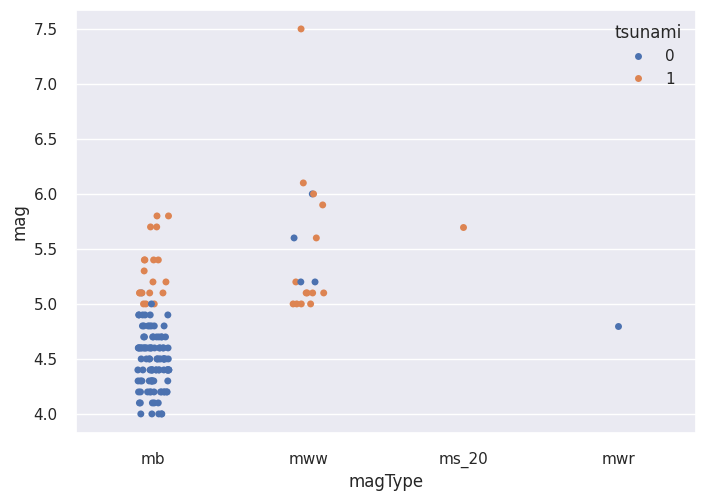

In [5]:
sns.stripplot(
x='magType',
y='mag',
hue='tsunami',
data=quakes.query('parsed_place == "Indonesia"')
)

#swarmplot()
The bee swarm plot helps address this issue be keeping the points from overlapping. Notice how many more points we can see for the blue section of the mb magType :

<Axes: xlabel='magType', ylabel='mag'>

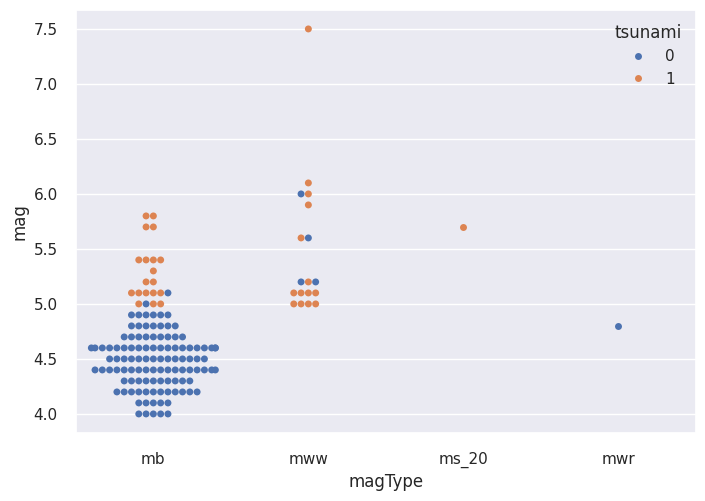

In [6]:
sns.swarmplot(
x='magType',
y='mag',
hue='tsunami',
data=quakes.query('parsed_place == "Indonesia"')
)

#Correlations and Heatmaps
#heatmap()
An easier way to create correlation matrix is to use seaborn :

<Axes: >

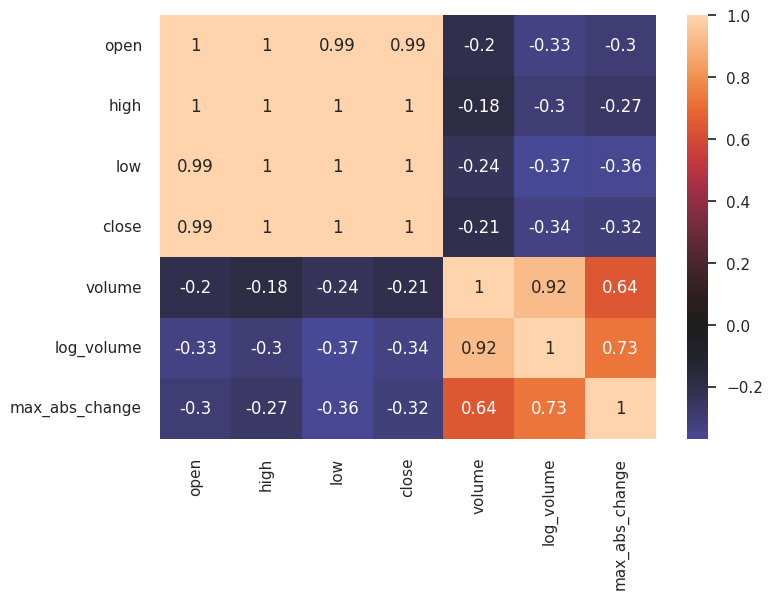

In [7]:
sns.heatmap(
fb.sort_index().assign(
log_volume=np.log(fb.volume),
max_abs_change=fb.high - fb.low
).corr(), annot=True, center=0
)


#pairplot()
The pair plot is seaborn's answer to the scatter matrix we saw in the pandas subplotting notebook:

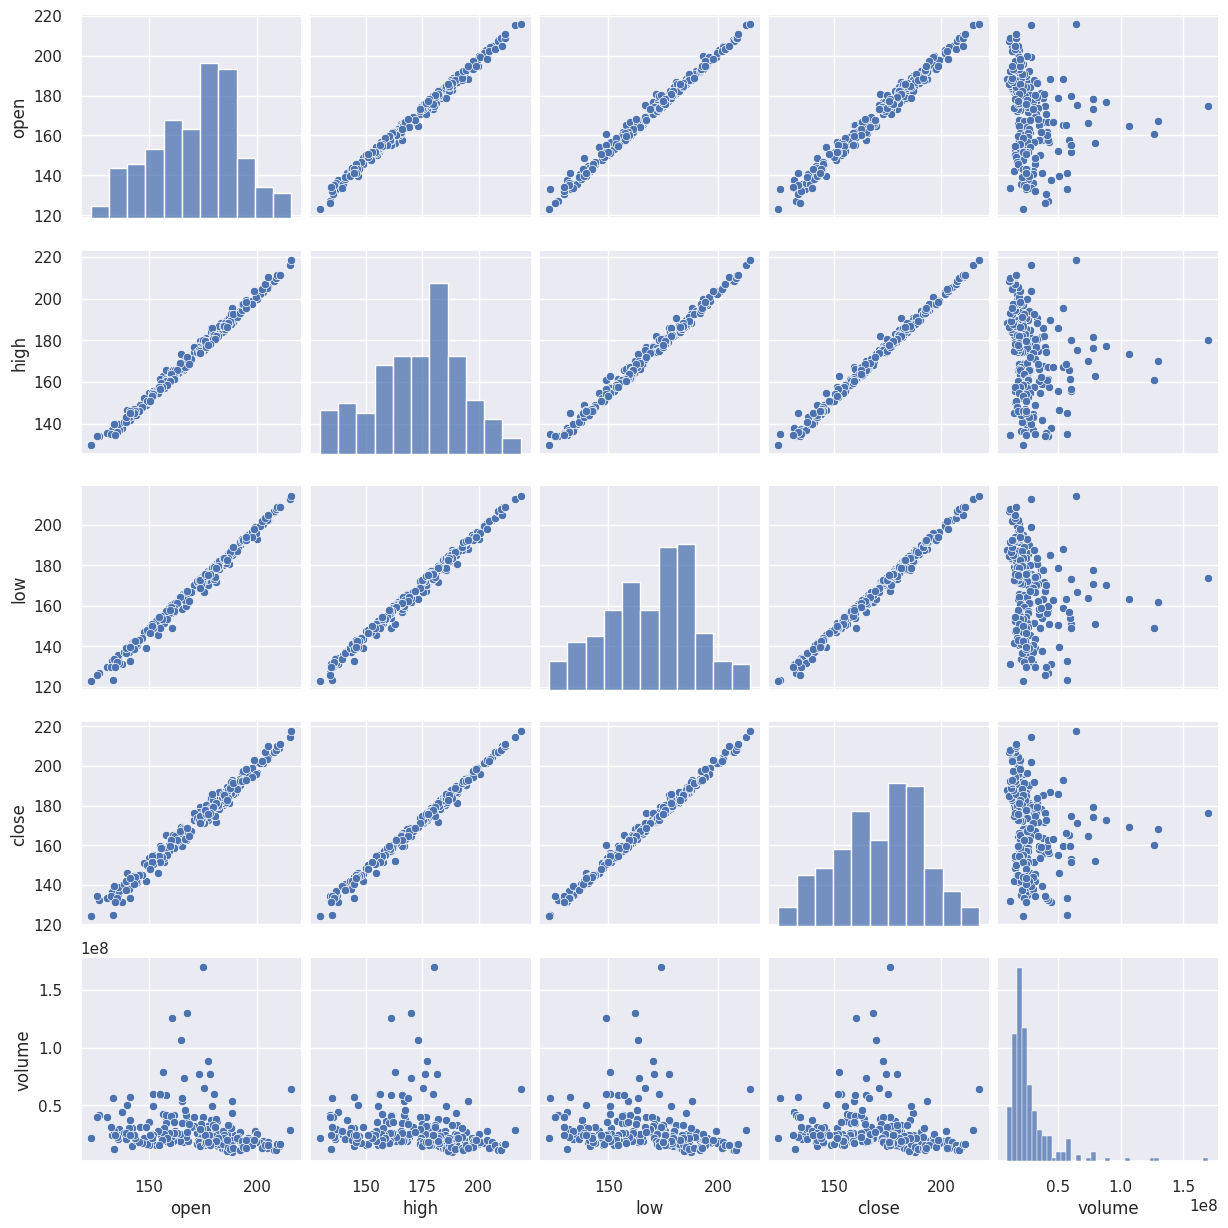

In [8]:
sns.pairplot(fb)

Just as with pandas we can specify what to show along the diagonal; however, seaborn also allows us to color the data based on another column (or other data with the
same shape):

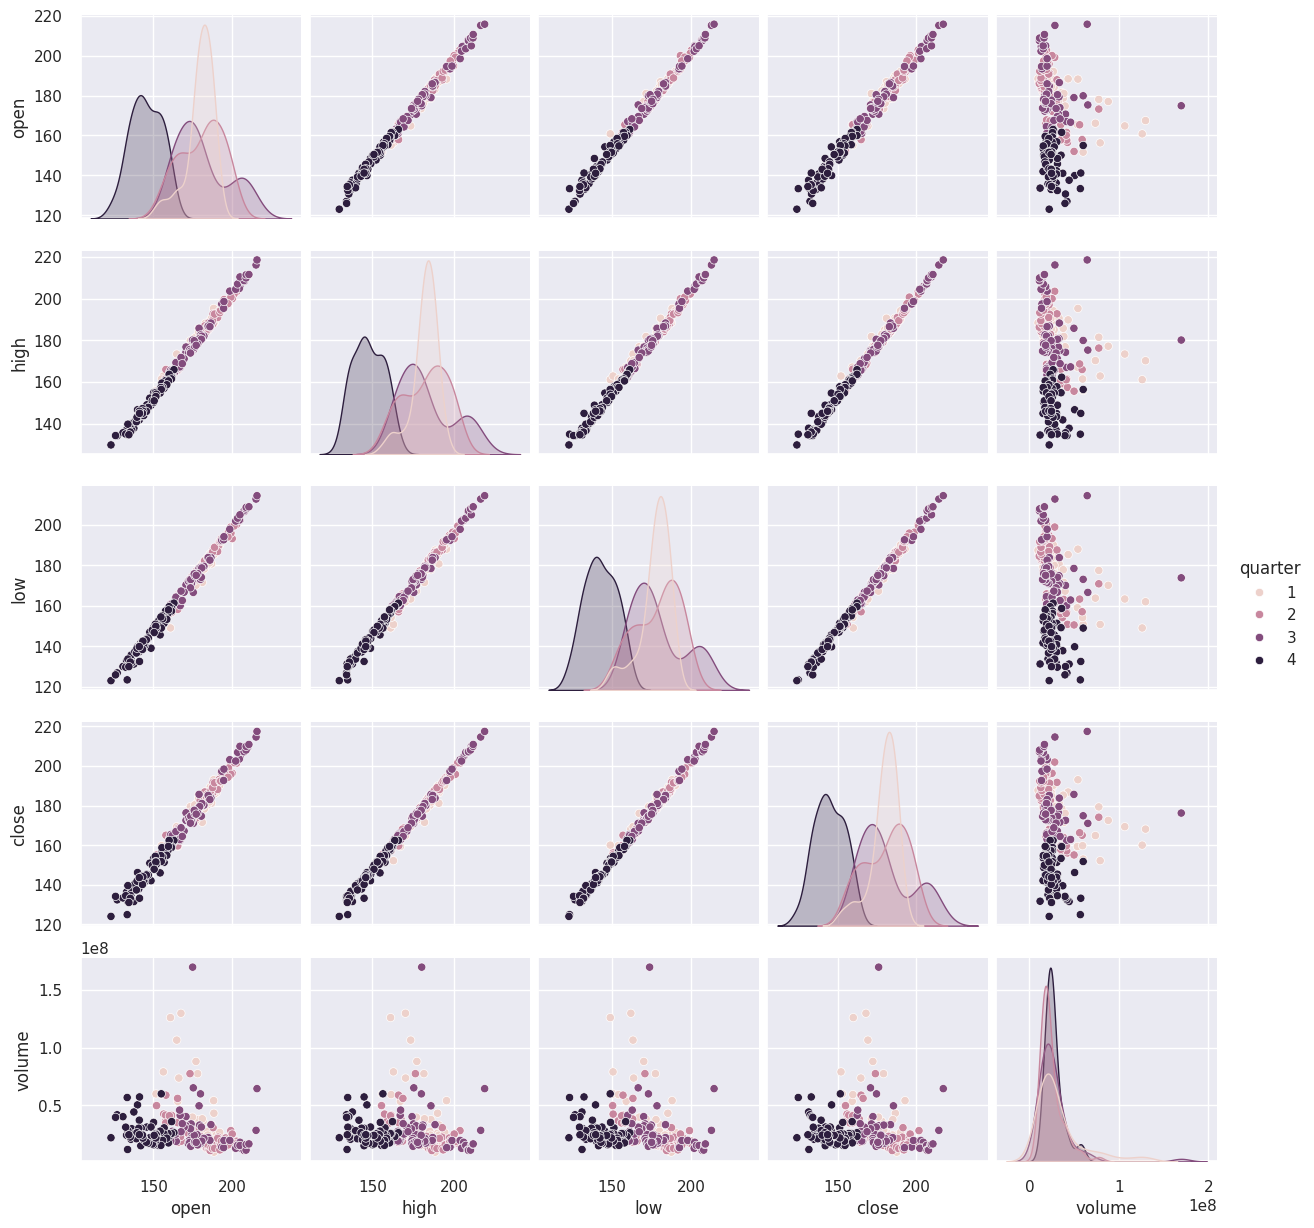

In [9]:
sns.pairplot(
fb.assign(quarter=lambda x: x.index.quarter),
diag_kind='kde',
hue='quarter'
)

**Supplementary Activity**<br>
Using the CSV files provided and what we have learned so far in this module complete the following exercises:

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8')
sns.set_theme()

In [11]:
fb = pd.read_csv('fb_stock_prices_2018.csv', parse_dates=['date'])
eq = pd.read_csv('earthquakes-1.csv')

1. Using seaborn, create a heatmap to visualize the correlation coefficients between earthquake magnitude and whether there was a tsunami with the magType of mb.

<Axes: >

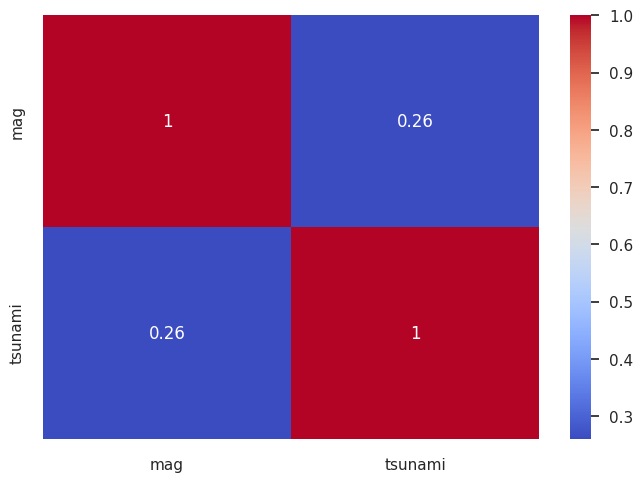

In [12]:
corr = eq[['mag', 'tsunami']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')


2. Create a box plot of Facebook volume traded and closing prices, and draw reference lines for the bounds of a Tukey fence with a multiplier of 1.5. The bounds will be at Q1 - 1.5 * IQR and Q3 + 1.5 * IQR. Be sure to use the quantile() method on the data to make this easier. (Pick whichever orientation you prefer for the plot, but make sure to use subplots.)

In [16]:
q1 = fb['close'].quantile(0.25)
q3 = fb['close'].quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr


In [15]:
q1 = fb['close'].quantile(0.25)
q3 = fb['close'].quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

3. Fill in the area between the bounds in the plot from exercise #2.

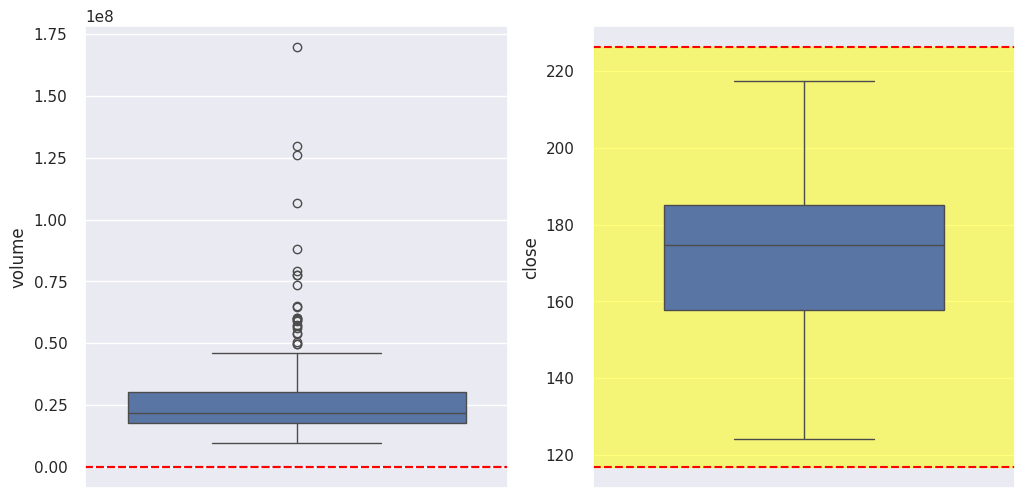

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
sns.boxplot(y=fb['volume'], ax=axes[0])
sns.boxplot(y=fb['close'], ax=axes[1])
for ax in axes:
    ax.axhline(lower, color='red', linestyle='--')
    ax.axhline(upper, color='red', linestyle='--')
    axes[1].fill_betweenx([lower, upper], x1=0, x2=1, color='yellow', alpha=0.3, transform=axes[1].get_yaxis_transform())


4. Use axvspan() to shade a rectangle from '2018-07-25' to '2018-07-31', which marks the large decline in Facebook price on a line plot of the closing price.


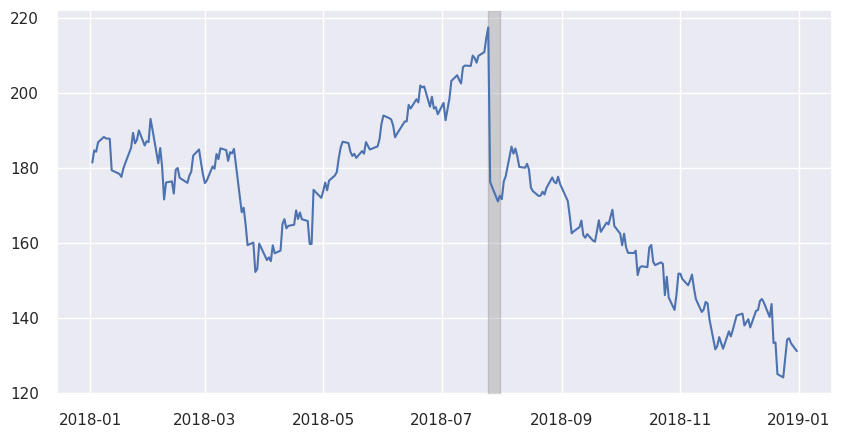

In [18]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(fb['date'], fb['close'])
ax.axvspan(pd.Timestamp('2018-07-25'), pd.Timestamp('2018-07-31'), color='gray', alpha=0.3)
events = {
    '2018-07-25': 'Disappointing user growth',
    '2018-03-19': 'Cambridge Analytica story',
    '2018-03-20': 'FTC investigation'
}

5. Using the Facebook stock price data, annotate the following three events on a line plot of the closing price:

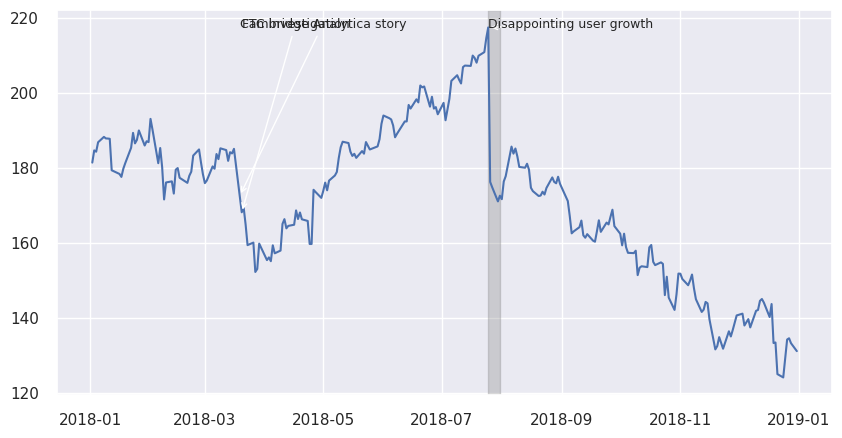

In [19]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(fb['date'], fb['close'])
ax.axvspan(pd.Timestamp('2018-07-25'), pd.Timestamp('2018-07-31'), color='gray', alpha=0.3)
events = {
    '2018-07-25': 'Disappointing user growth',
    '2018-03-19': 'Cambridge Analytica story',
    '2018-03-20': 'FTC investigation'
}
for date, label in events.items():
    ax.annotate(label, xy=(pd.Timestamp(date), fb.loc[fb['date'] == date, 'close'].values[0]),
                xytext=(pd.Timestamp(date), fb['close'].max()),
                arrowprops=dict(arrowstyle='->'), fontsize=9)


6. Modify the reg_resid_plots() function to use a matplotlib colormap instead of cycling between two colors. Remember, for this use case, we should pick a qualitative colormap or make our own.

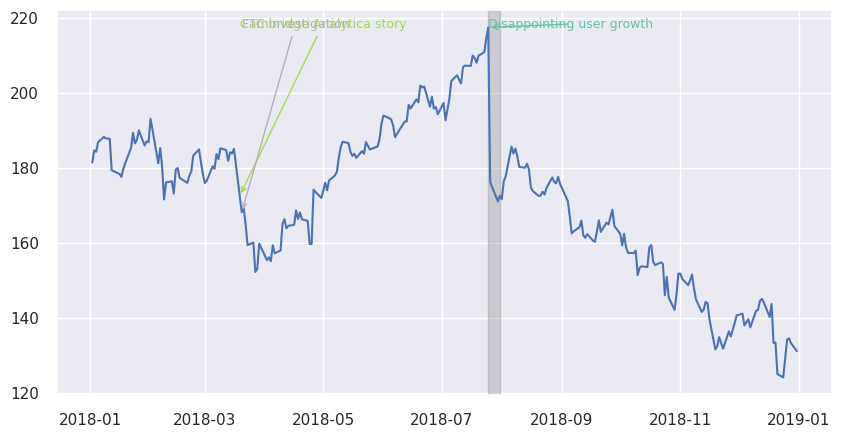

In [20]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(fb['date'], fb['close'])

ax.axvspan(pd.Timestamp('2018-07-25'), pd.Timestamp('2018-07-31'),
           color='gray', alpha=0.3)

events = {
    '2018-07-25': 'Disappointing user growth',
    '2018-03-19': 'Cambridge Analytica story',
    '2018-03-20': 'FTC investigation'
}


cmap = plt.get_cmap('Set2')
colors = cmap(np.linspace(0, 1, len(events)))


for (date, label), color in zip(events.items(), colors):
    ax.annotate(label,
                xy=(pd.Timestamp(date),
                    fb.loc[fb['date'] == date, 'close'].values[0]),
                xytext=(pd.Timestamp(date), fb['close'].max()),
                arrowprops=dict(arrowstyle='->', color=color),
                fontsize=9, color=color)

**Conclusion**<br>
By switching len(model) to len(events) and generating colors based on the number of events, your visualization now works smoothly. Each annotation is assigned a distinct color from the colormap, the highlighted span is clear, and the event markers are properly labeled. This makes the chart both informative and visually appealing, allowing you to quickly connect stock price movements with key events.